<a href="https://colab.research.google.com/github/SathyaPrakashD/MachineLearning/blob/main/4_3_Precision_and_Recall_Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# Import the pandas library for data manipulation
import pandas as pd
# Import the numpy library for numerical operations
import numpy as np

# Import the matplotlib.pyplot library for plotting
import matplotlib.pyplot as plt

In [18]:
# Import function to split data into training and testing sets
from sklearn.model_selection import train_test_split
# Import DictVectorizer for one-hot encoding categorical features
from sklearn.feature_extraction import DictVectorizer
# Import LogisticRegression for building the classification model
from sklearn.linear_model import LogisticRegression

In [19]:
# Import the kagglehub library to access Kaggle datasets
import kagglehub

# Download the latest version of the dataset using kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

# Print the path where the dataset files are located
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [20]:
# Import the pandas library for data manipulation
import pandas as pd

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")
# Display the DataFrame to show its contents
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [21]:
# Convert column names to lowercase and replace spaces with underscores
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Identify categorical columns (object dtype)
categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)
for c in categorical_columns:
  # Convert values in categorical columns to lowercase and replace spaces with underscores
    df[c] = df[c].str.lower().str.replace(' ', '_')

# Convert 'totalcharges' to numeric, coercing errors to NaN
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
# Fill any missing 'totalcharges' values with 0
df.totalcharges = df.totalcharges.fillna(0)
# Convert 'churn' column from 'yes'/'no' to 1/0 integers
df.churn = (df.churn == 'yes').astype(int)

In [22]:
# Split data into full training (80%) and test (20%) sets
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
# Split full training into training (75% of full train) and validation (25% of full train) sets
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

# Reset index for training DataFrame
df_train = df_train.reset_index(drop=True)
# Reset index for validation DataFrame
df_val = df_val.reset_index(drop=True)
# Reset index for test DataFrame
df_test = df_test.reset_index(drop=True)

# Extract 'churn' target variable for training set
y_train = df_train.churn.values
# Extract 'churn' target variable for validation set
y_val = df_val.churn.values
# Extract 'churn' target variable for test set
y_test = df_test.churn.values

# Remove 'churn' column from training features
del df_train['churn']
# Remove 'churn' column from validation features
del df_val['churn']
# Remove 'churn' column from test features
del df_test['churn']

In [23]:
# Define list of numerical features
numerical = ['tenure', 'monthlycharges', 'totalcharges']

# Define list of categorical features
categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [24]:
# Initialize DictVectorizer for one-hot encoding, ensuring dense output
dv = DictVectorizer(sparse=False)

# Convert training data features to a list of dictionaries
train_dict = df_train[categorical + numerical].to_dict(orient='records')
# Fit DictVectorizer and transform training data
X_train = dv.fit_transform(train_dict)

# Initialize Logistic Regression model
model = LogisticRegression()
# Train the Logistic Regression model using the transformed training features and target variable
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

This code block calculates the predicted probabilities of churn for the validation set and then converts these probabilities into binary churn decisions based on a 0.5 threshold.

*   `y_pred = model.predict_proba(X_val)[:, 1]`: This line uses the trained `model` to predict the probability of churn for each customer in the `X_val` (validation) dataset. `predict_proba()` returns probabilities for both classes, and `[:, 1]` selects only the probabilities for the positive class (churn).
*   `churn_decision = (y_pred >= 0.5)`: This line converts the predicted probabilities into a binary decision. If a customer's churn probability (`y_pred`) is 0.5 or higher, `churn_decision` for that customer will be `True` (predicted to churn); otherwise, it will be `False` (predicted not to churn). This operation is element-wise, meaning the `churn_decision` array has the same length as `y_pred` and `y_val`.

In [25]:
# Convert validation data features to a list of dictionaries
val_dict = df_val[categorical + numerical].to_dict(orient='records')
# Transform validation data using the fitted DictVectorizer
X_val = dv.transform(val_dict)

# Get predicted probabilities for the positive class (churn=1) on the validation set
y_pred = model.predict_proba(X_val)[:, 1]
print(y_pred.round(3))
print(len(y_pred))

# Classify as churn if probability is 0.5 or higher
churn_decision = (y_pred >= 0.5)
print(len(churn_decision))

# Calculate the accuracy of the model on the validation set
(y_val == churn_decision).mean()

[0.008 0.21  0.224 ... 0.15  0.777 0.81 ]
1409
1409


np.float64(0.801277501774308)

## Accuracy and dummy Model

- Evaluate the model on different thresholds
- Arranging them in a table

In [26]:
len(y_val)

1409

This line calculates the accuracy of the model on the validation set.

*   `(y_val == churn_decision)`: This performs an element-wise comparison between the actual churn values (`y_val`, which are 0s and 1s) and the model's predicted churn decisions (`churn_decision`, which are True/False). It creates a new boolean array where `True` indicates a correct prediction and `False` indicates an incorrect prediction.
*   `.mean()`: When applied to a boolean array, `.mean()` treats `True` as 1 and `False` as 0. Therefore, the result is the proportion of `True` values, which represents the overall accuracy of the model.

In [27]:
(y_val == churn_decision).mean()

np.float64(0.801277501774308)

This line calculates the total number of correct predictions made by the model on the validation set.

*   `(y_val == churn_decision)`: Similar to the accuracy calculation, this creates a boolean array where `True` indicates a correct prediction and `False` an incorrect one.
*   `.sum()`: When applied to a boolean array, `.sum()` treats `True` as 1 and `False` as 0. Therefore, the result is the total count of `True` values, representing the absolute number of correct predictions.

In [28]:
(y_val == churn_decision).sum()

np.int64(1129)

In [29]:
1129/1409

0.801277501774308

This is the accuracy. total number of correct prediction divided by total number of prediction in y_val.

 We classified the churn decision threshold. If probability is 0.5 or higher.
churn_decision = (y_pred >= 0.5)

Let us see, if increasing or decreasing the threshold from 0.5 will increase or decrease the threshold.

Lets create a array of threshold using linspace.

In [30]:
thresholds = np.linspace(0, 1, 21)
thresholds

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

Lets iterate over array of thresholds

In [31]:
scores = []

for t in thresholds:
  churn_decision = (y_pred >= t)
  score = (y_val == churn_decision).mean()
  scores.append(score)
  #print(t, "-- " ,(y_val == churn_decision).mean())
  print('%.2f %.3f' % (t,score))


0.00 0.274
0.05 0.509
0.10 0.598
0.15 0.664
0.20 0.707
0.25 0.737
0.30 0.759
0.35 0.766
0.40 0.780
0.45 0.793
0.50 0.801
0.55 0.798
0.60 0.797
0.65 0.784
0.70 0.765
0.75 0.744
0.80 0.730
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


From the above the output we see  that 0.5 is infact the best threshold

**0.5 - 0.801**

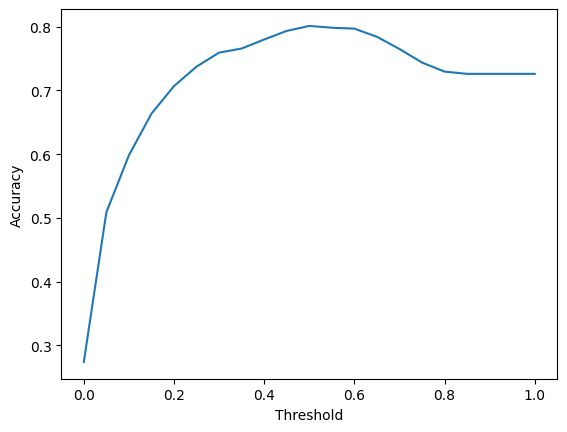

In [32]:
plt.plot(thresholds, scores)
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.show()
#

- Above graph tells that there is no customer churns for Threashold above 1.0.

- For a model with threshold = 1.0 has the accuracy of 73%.

Important question to observe.

- A Dummy model with threshold greater or equal to 1.0 has a accuracy of 0.73 or 73% and the above trained model has a accuracy of 80%.

- **Why do we need to train the model for only 7% difference in performance**

  - This is the main issue with Accuracy. Accuracy doesn't tell us about the performance of the model.

  - As per the class distribution in the data only 27% of the users are churning and remaining 73% are non-chruning. So there is almost 3:1 class imbalance between churning and non-chruning users.

# Confusion Table

 - Different types of errors and correct decisions.
 - Arranging them in table

In [33]:
actual_postives = (y_val == 1)
actual_negatives = (y_val == 0)

In [35]:
t = 0.5
predicted_positives = (y_pred >= t)
predicted_negatives = (y_pred < t)


**True Positive = Predicted Postives and Actual postives**

In [37]:
tp = (predicted_positives & actual_postives).sum()
tp

np.int64(214)

**True Negatives = Predicted Negatives and Actual Negatives**

In [38]:
tn = (predicted_negatives & actual_negatives).sum()
tn

np.int64(915)

**False Postives = Predicted Postive and actual Negative**

In [39]:
fp = (predicted_positives & actual_negatives).sum()
fp

np.int64(108)

**False Negatives = Predicted Negative and Actual Negative**

In [43]:
fn = (predicted_negatives & actual_postives).sum()
fn

np.int64(172)

In [44]:
tp,tn,fp,fn,(tp+tn+fp+fn),len(y_val)

(np.int64(214),
 np.int64(915),
 np.int64(108),
 np.int64(172),
 np.int64(1409),
 1409)

**Confusion matrix**

In [46]:
confusion_matrix = np.array([
    [tn,fp],
    [fn,tp]
])

confusion_matrix

array([[915, 108],
       [172, 214]])

In [48]:
confusion_matrix = np.array([
    [tn,fp],
    [fn,tp]
])

(confusion_matrix / confusion_matrix.sum()).round(3)

array([[0.649, 0.077],
       [0.122, 0.152]])

# Session 01 — Confusion Matrix
**AI Curriculum | Domain 1.4 — Evaluation Metrics**
**Date:** April 2026 | **Dataset:** Telco Customer Churn

---

## 📍 Session Brief

| | |
|---|---|
| 🎯 **Focus** | Confusion Matrix — understand, build, interpret |
| ✅ **Done When** | Can read any cell and state what it costs the business |
| 🏆 **Show-Off Checkpoint** | Fully annotated confusion matrix notebook — raw counts + percentages + business cost per cell |
| ⬜ **Open Loops** | Precision/Recall, Calibration, K-fold, ML Canvas |

---

## 🧠 Concept: Why Accuracy Alone Isn't Enough

### The Dummy Model Problem

A model that predicts **"no churn" for every single customer** scores **73% accuracy** on this dataset — because 73% of customers genuinely don't churn. This exploits **class imbalance**.

Our trained model scores **80%** — only 7% better. But that headline number hides everything important.

> **Key insight locked:** Accuracy fails to expose False Positives and False Negatives — which is where the actual business impact lives.

---

## 🔀 How the Confusion Matrix is Built

The model runs **once**. It produces one score per customer: `g(xᵢ)`.

You then have **two independent sources of truth**:

| Split | Source | Question |
|---|---|---|
| **Split 1** | `y_val` | What *actually* happened? (ground truth) |
| **Split 2** | `g(xᵢ) ≥ threshold` | What did the *model predict*? |

A **logical AND** (`&`) is applied between both arrays for each customer simultaneously. The result is 4 buckets.

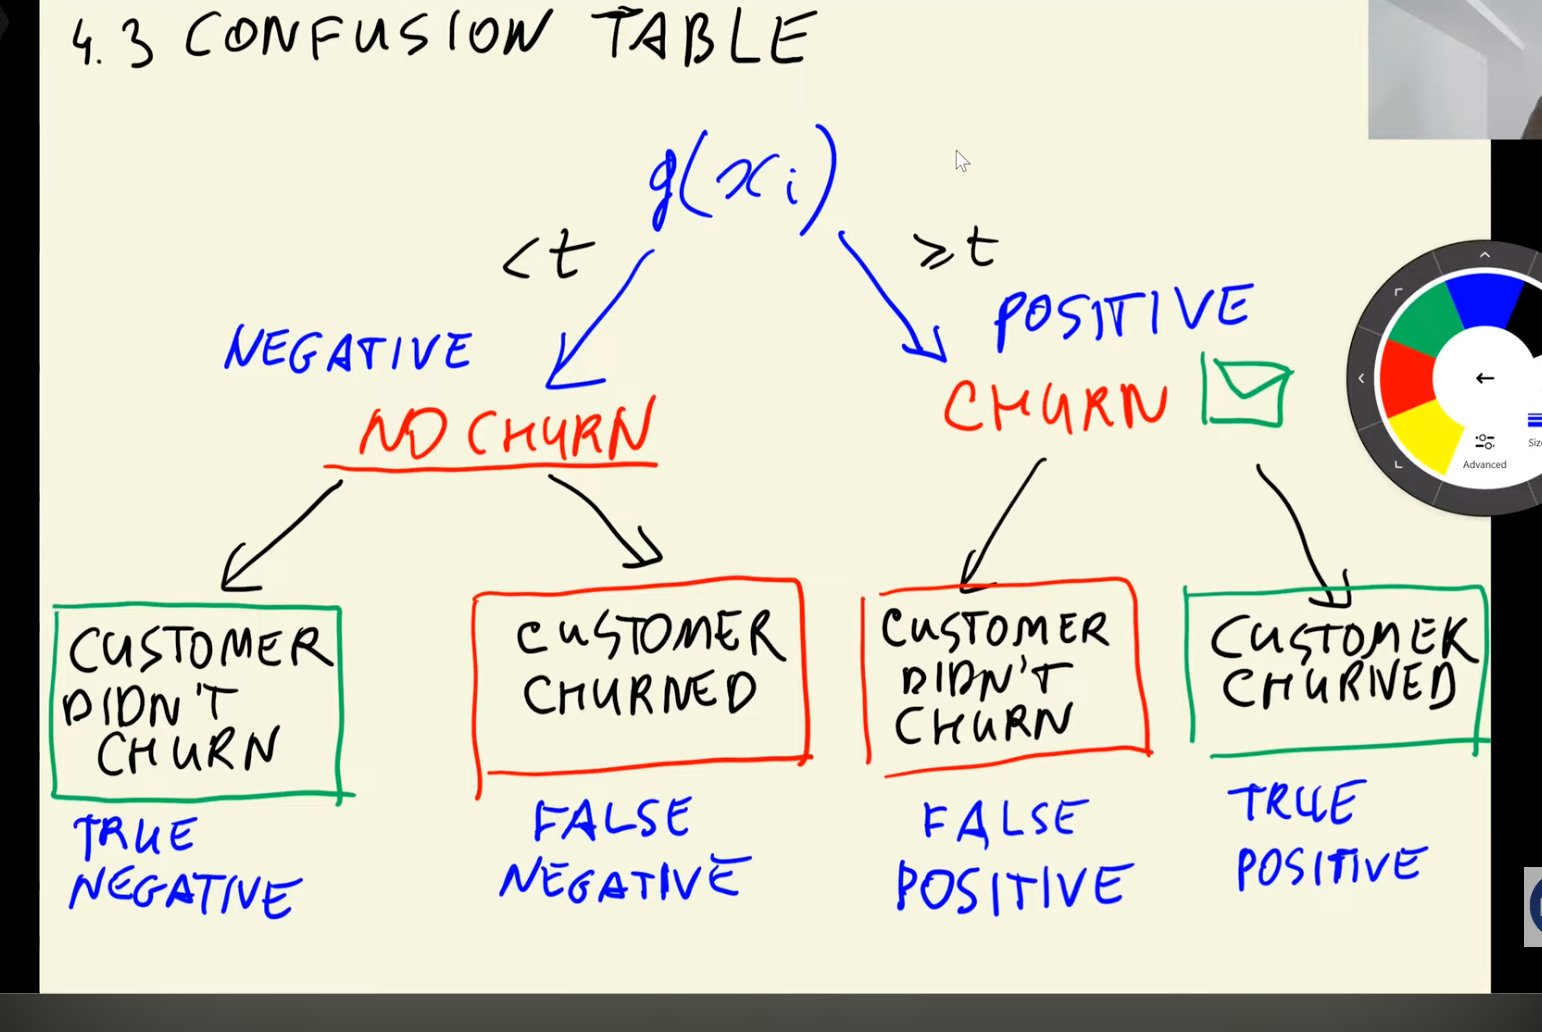
*Fig 1 — Prediction decision tree: score vs threshold determines positive/negative label*

---

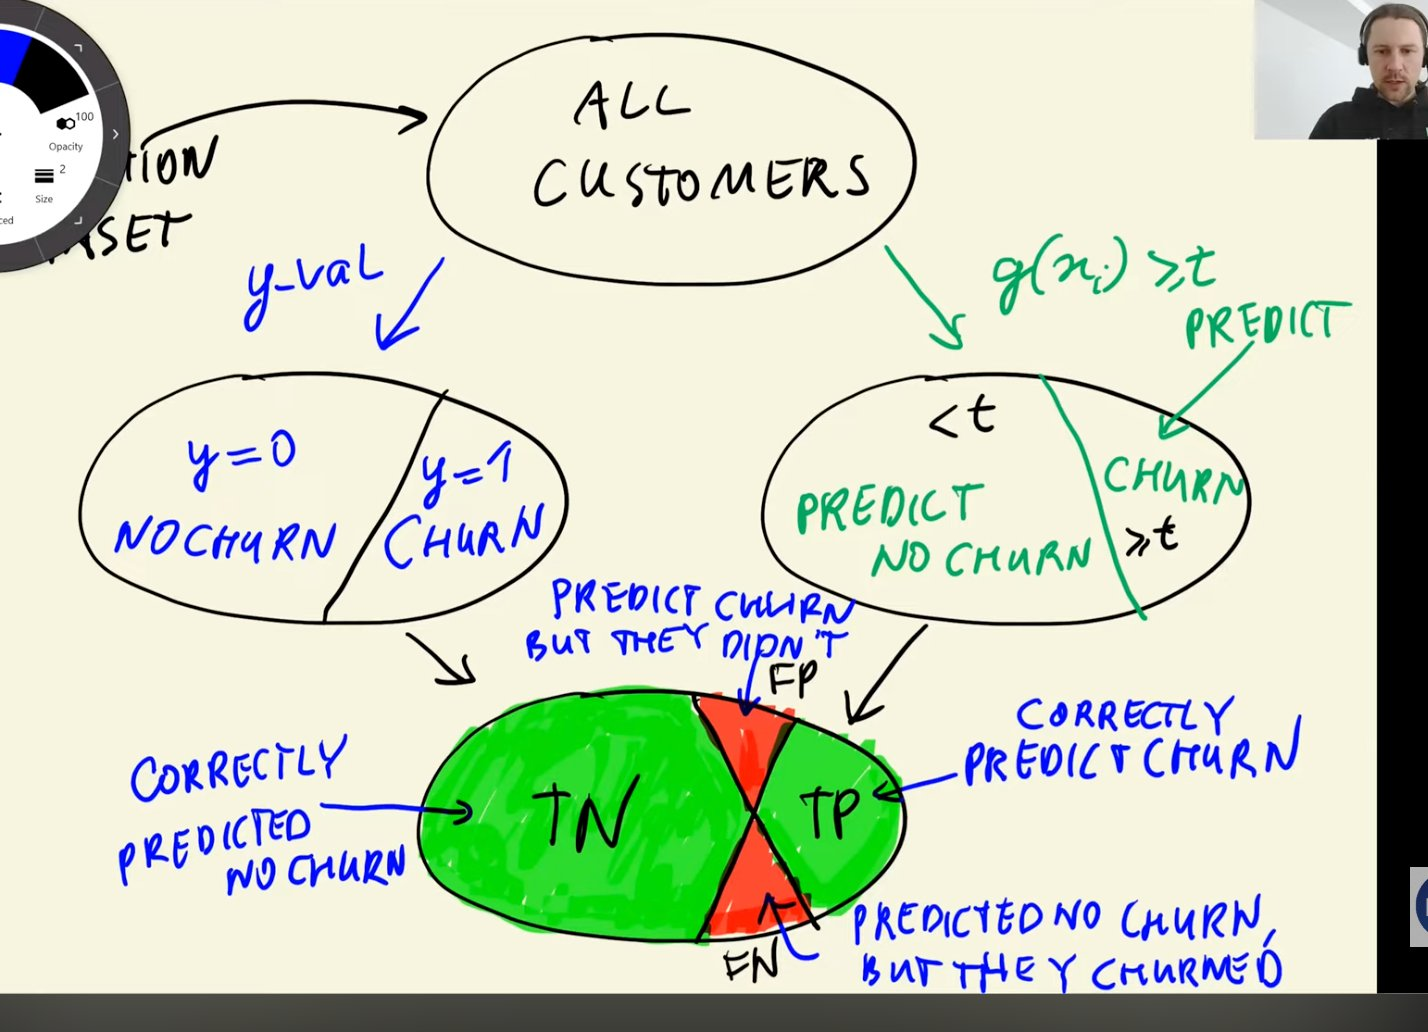
*Fig 2 — Two independent splits (actual vs predicted) overlaid to produce 4 outcome regions*

---

## 🟩🟥 The Four Cells

Each cell requires **both conditions** to be true simultaneously:

| Cell | Condition | Plain English |
|---|---|---|
| **TN** | `g(xᵢ) < t` AND `y = 0` | Predicted no churn. Actually didn't churn. ✅ |
| **TP** | `g(xᵢ) ≥ t` AND `y = 1` | Predicted churn. Actually churned. ✅ |
| **FP** | `g(xᵢ) ≥ t` AND `y = 0` | Predicted churn. Actually didn't. ❌ |
| **FN** | `g(xᵢ) < t` AND `y = 1` | Predicted no churn. Actually churned. ❌ |

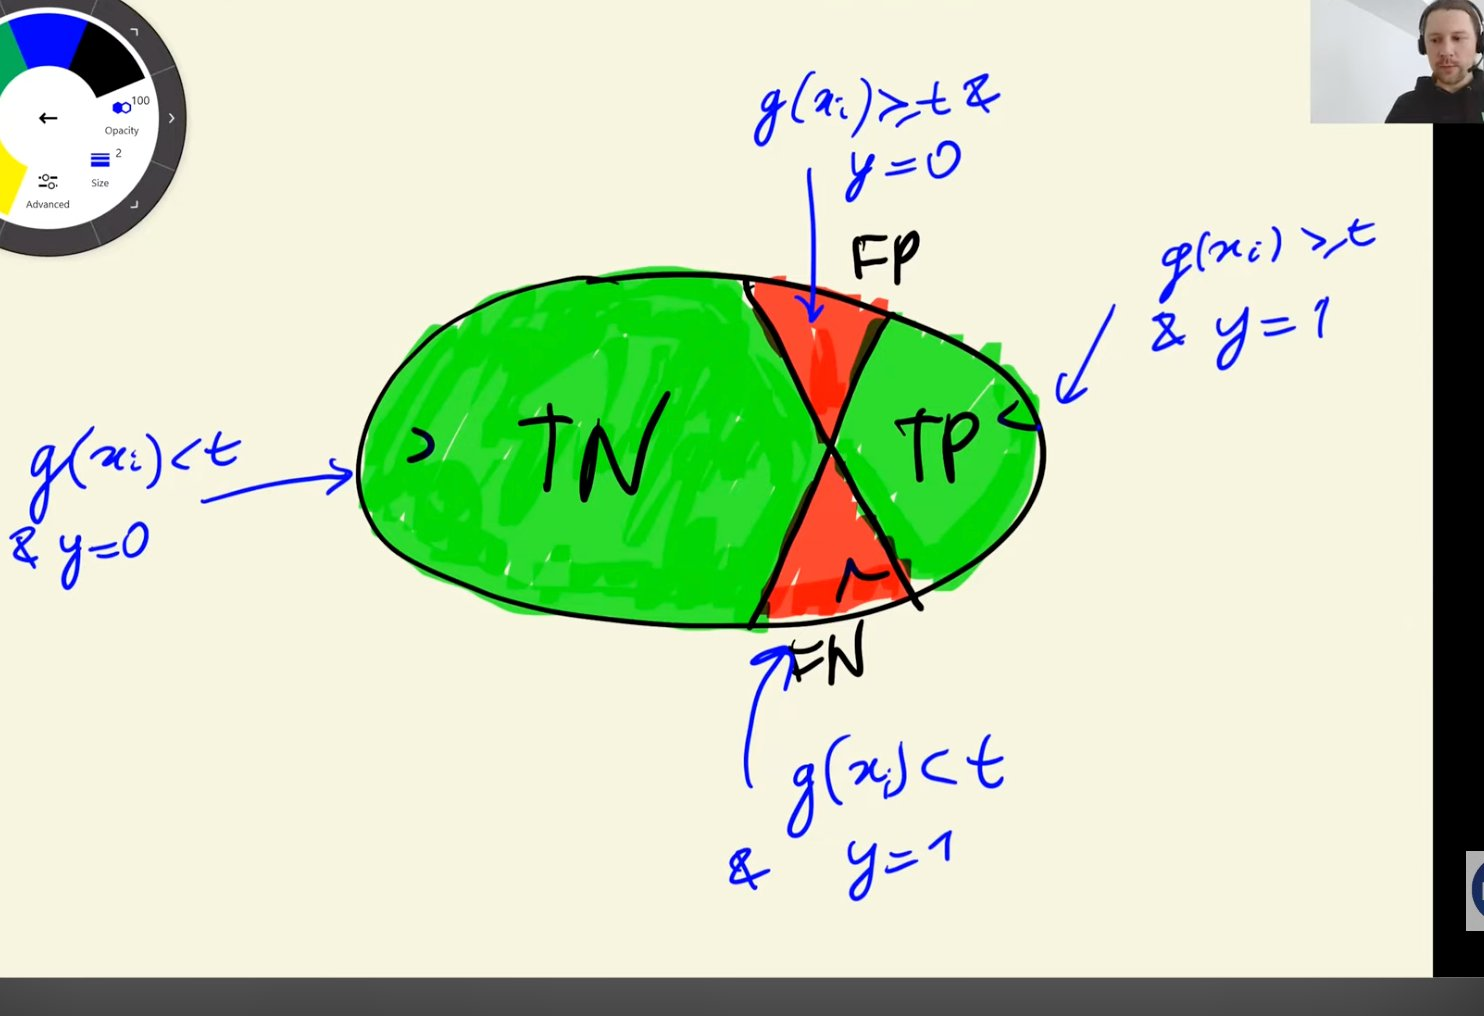
*Fig 3 — Each cell requires two conditions to be true simultaneously (logical AND)*

---

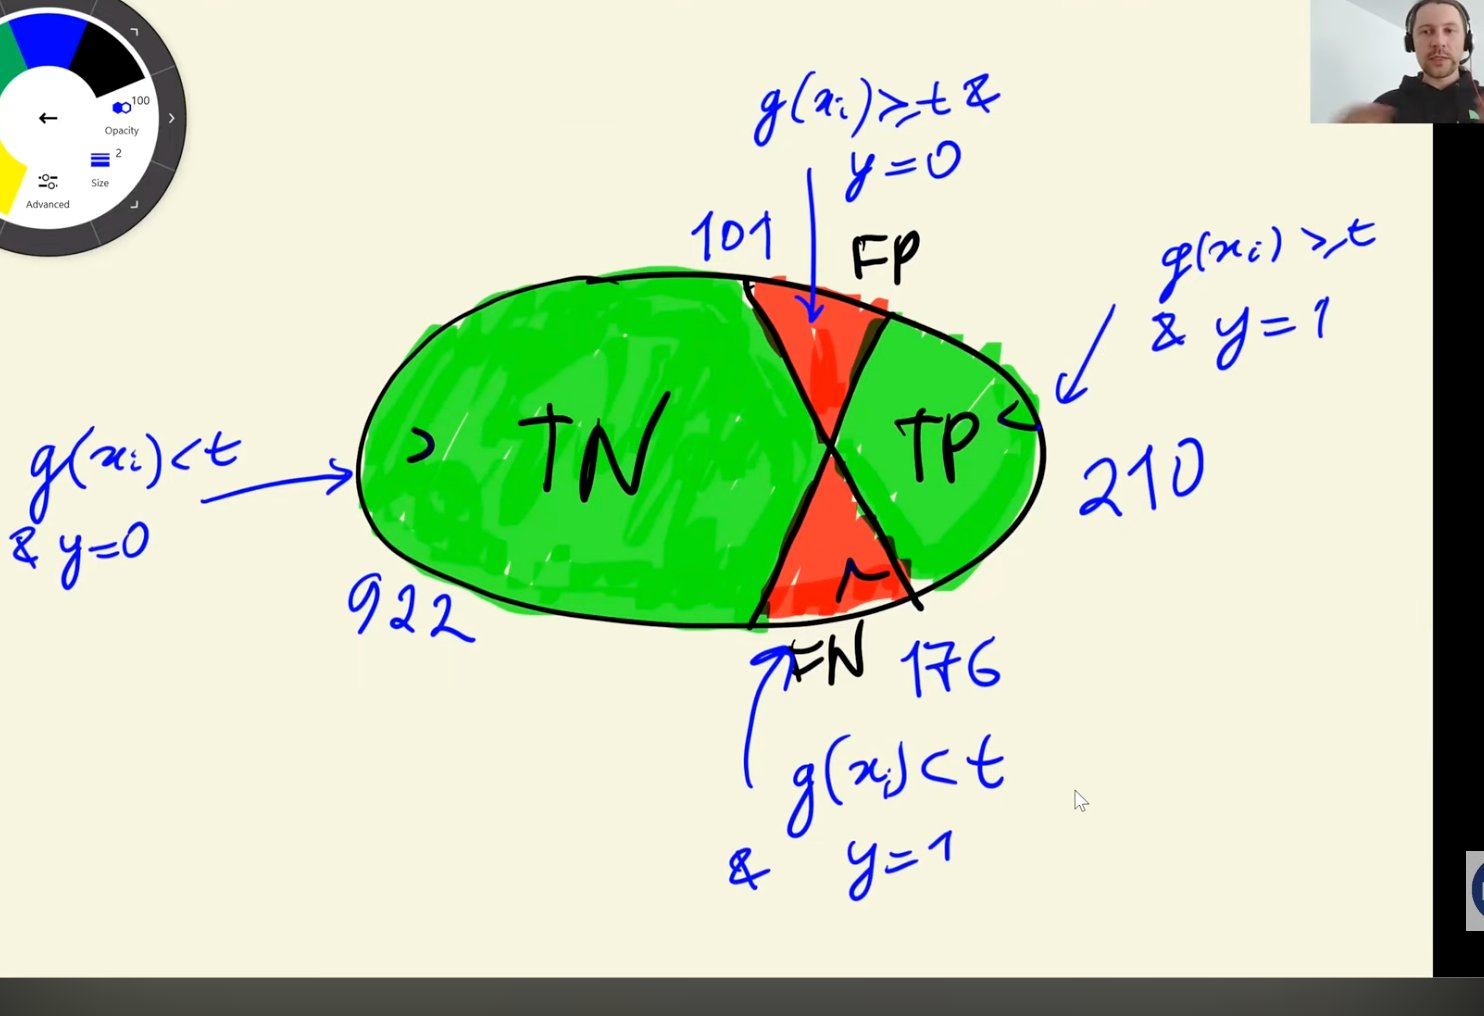
*Fig 4 — Actual counts: TN=922, FP=101, FN=176, TP=210*

---

## 📊 The Confusion Matrix

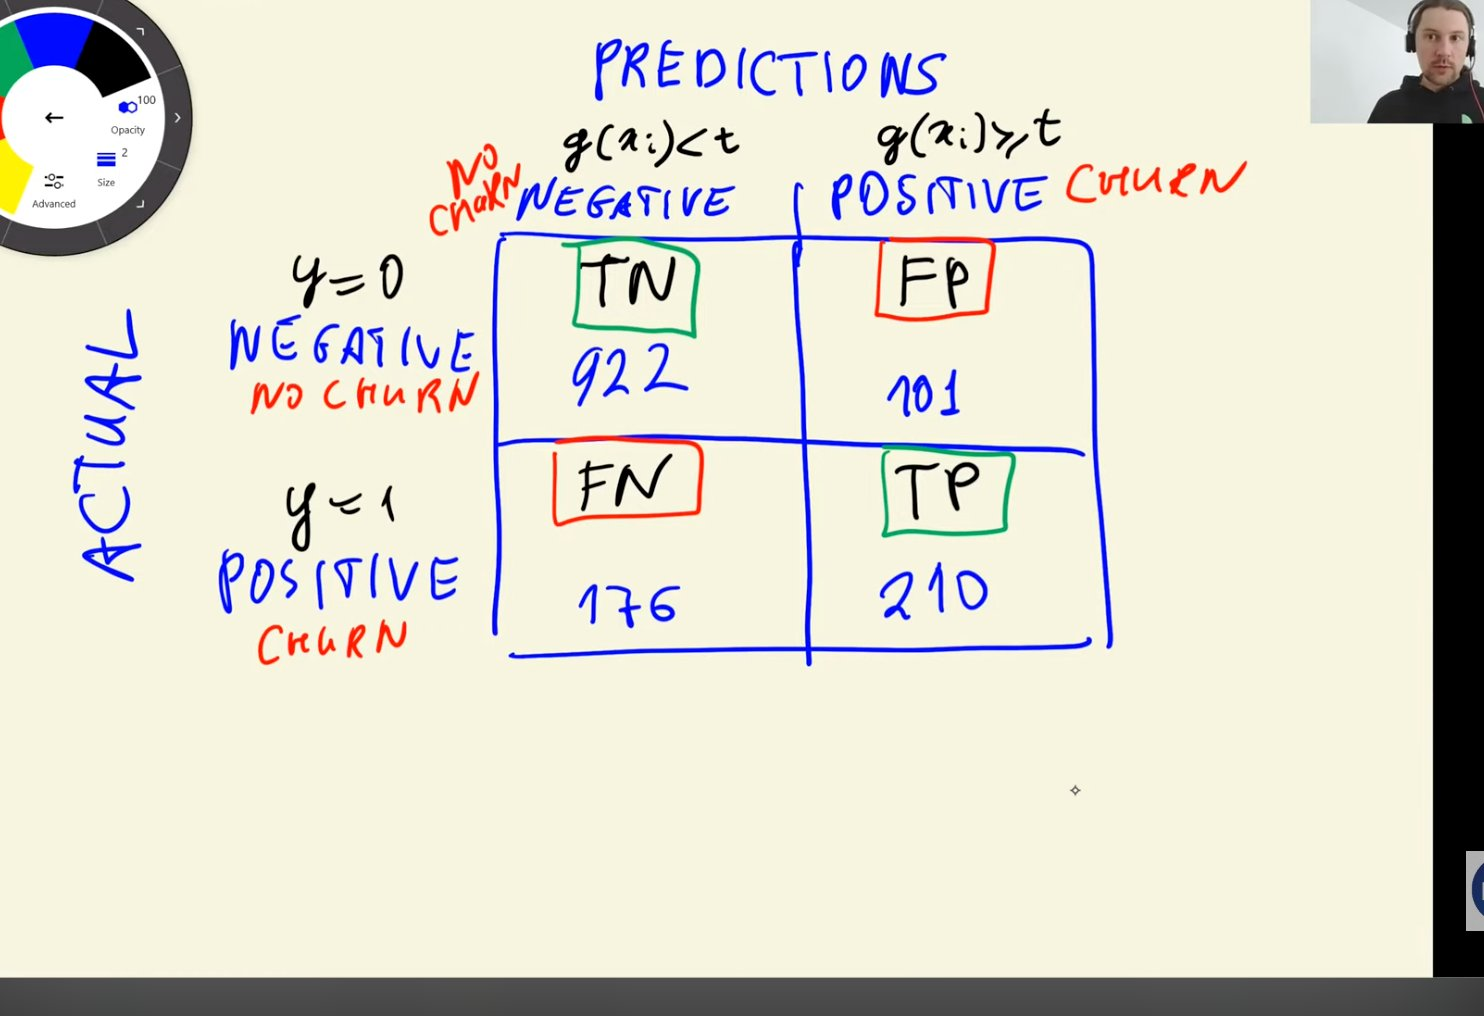
*Fig 5 — Confusion matrix: rows = actual labels, columns = predicted labels*

```
                  Predicted No Churn    Predicted Churn
Actual No Churn        TN = 922            FP = 101
Actual Churn           FN = 176            TP = 210
```

---

## 📐 Normalised View

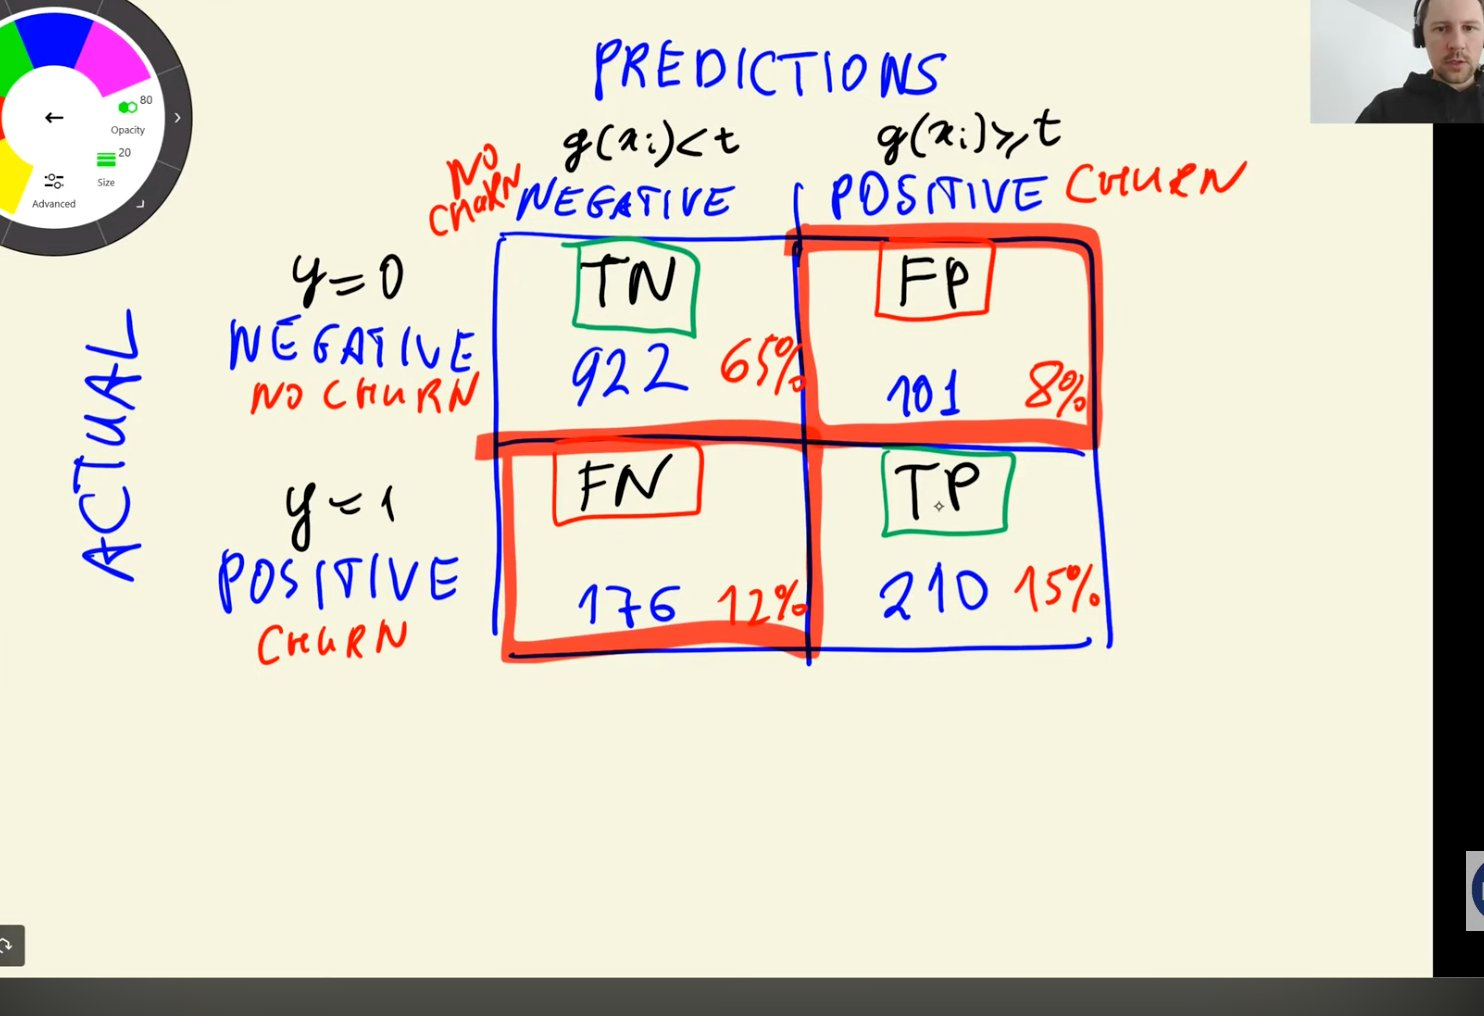
*Fig 6 — Percentages: TN=65%, FP=8%, FN=12%, TP=15%*

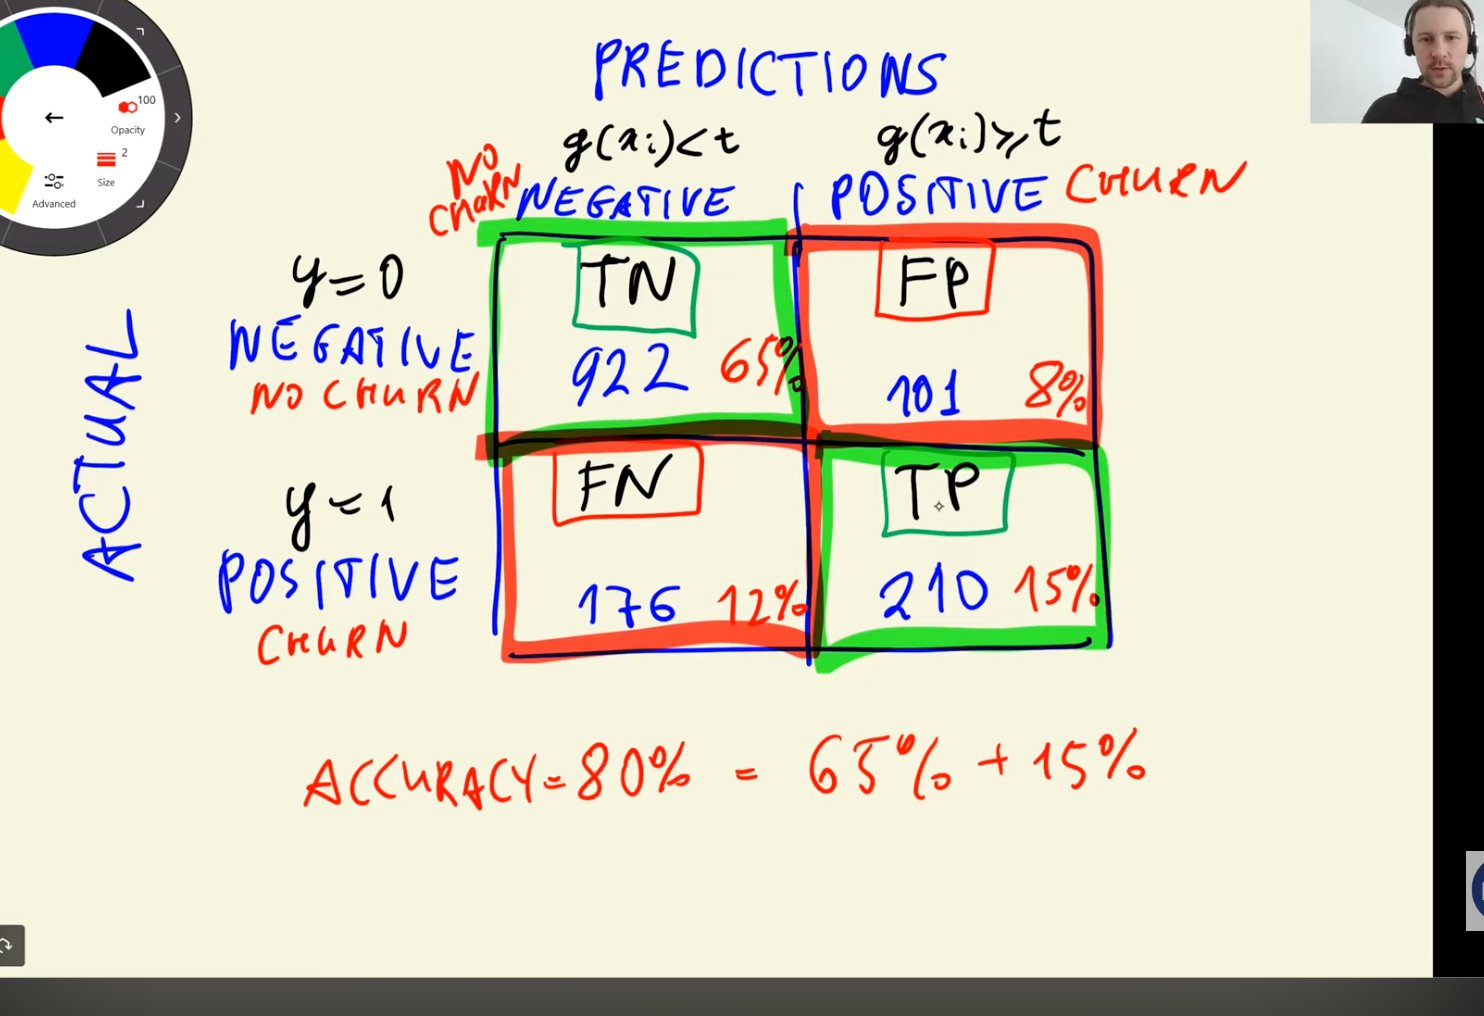
*Fig 7 — Accuracy = TN% + TP% = 65% + 15% = 80%*

---

## 💰 Business Cost Interpretation

| Cell | Count | % | Business Consequence |
|---|---|---|---|
| **TN** | 922 | 65% | Correct. No action. Zero cost. |
| **TP** | 210 | 15% | Correct. Sent discount. Customer retained. |
| **FP** | 101 | 8% | Sent discount to non-churner. Wasted ~£10/customer. |
| **FN** | 176 | 12% | Sent nothing. Customer churned. Revenue lost permanently. |

> **Critical asymmetry:** FN is the most expensive error — a customer who leaves stops paying forever. FP wastes a small discount. Accuracy treats TN and TP as equally valuable — but they are not. TN costs nothing to get right. TP requires action and saves revenue.

---

## ✅ Concepts Locked This Session

| Concept | Status | Evidence |
|---|---|---|
| Confusion matrix is built by logical AND of two arrays | ✅ Locked | Explained correctly in own words |
| Accuracy = TN% + TP% — and why this is misleading | ✅ Locked | Explained dummy model exploitation |
| Accuracy fails to expose FP and FN business impact | ✅ Locked | Stated correctly and unprompted |
| TN and TP are not equally valuable to the business | ✅ Locked | Explained why accuracy is not trustworthy |

---

## 🔨 Code Skeleton (In Progress)

```python
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Step 1: Load data
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC__Telco-Customer-Churn.csv')

# Step 2: Minimal prep
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X = df[features]
y = df['Churn']

# Step 3: Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: Train
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 5: Predict  <- FILL IN
y_pred = _______________

# Step 6: Build confusion matrix  <- FILL IN
cm = confusion_matrix(_______________, _______________)

# Step 7: Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Churn Confusion Matrix")
plt.show()
```

**Blanks to fill:**
1. `y_pred = ___` — what sklearn method gives predicted class labels (0 or 1)?
2. `confusion_matrix(___, ___)` — actual or predicted first? Why does order matter?

---

## ⬜ What's Next

- Complete the code skeleton (blanks above)
- Add normalised view (`normalize='all'`)
- Add business cost annotation per cell
- **Session 2:** Precision, Recall, F1 — built on top of this matrix

---

*Source material: MLOps Zoomcamp — Session 4, Lesson 3 (Confusion Table)*

# Session 01 — Confusion Matrix
**AI Curriculum | Domain 1.4 — Evaluation Metrics**
**Date:** April 2026 | **Dataset:** Telco Customer Churn

---

## 📍 Session Brief

| | |
|---|---|
| 🎯 **Focus** | Confusion Matrix — understand, build, interpret |
| ✅ **Done When** | Can read any cell and state what it costs the business |
| 🏆 **Show-Off Checkpoint** | Fully annotated confusion matrix notebook — raw counts + percentages + business cost per cell |
| ⬜ **Open Loops** | Precision/Recall, Calibration, K-fold, ML Canvas |

---

## 🧠 Concept: Why Accuracy Alone Isn't Enough

A model that predicts **"no churn" for every single customer** scores **73% accuracy** — because 73% of customers genuinely don't churn. This exploits **class imbalance**. Our trained model scores **80%** — only 7% better. That headline hides everything important.

> **Key insight locked:** Accuracy fails to expose False Positives and False Negatives — which is where the actual business impact lives.

---

## 🔀 How the Confusion Matrix is Built

The model runs **once**. It produces one score per customer: `g(xᵢ)`.

Two independent sources of truth are then compared:

| Split | Source | Question |
|---|---|---|
| **Split 1** | `y_val` | What *actually* happened? (ground truth) |
| **Split 2** | `g(xᵢ) ≥ threshold` | What did the *model predict*? |

A **logical AND** (`&`) is applied element-wise. Result: 4 buckets.

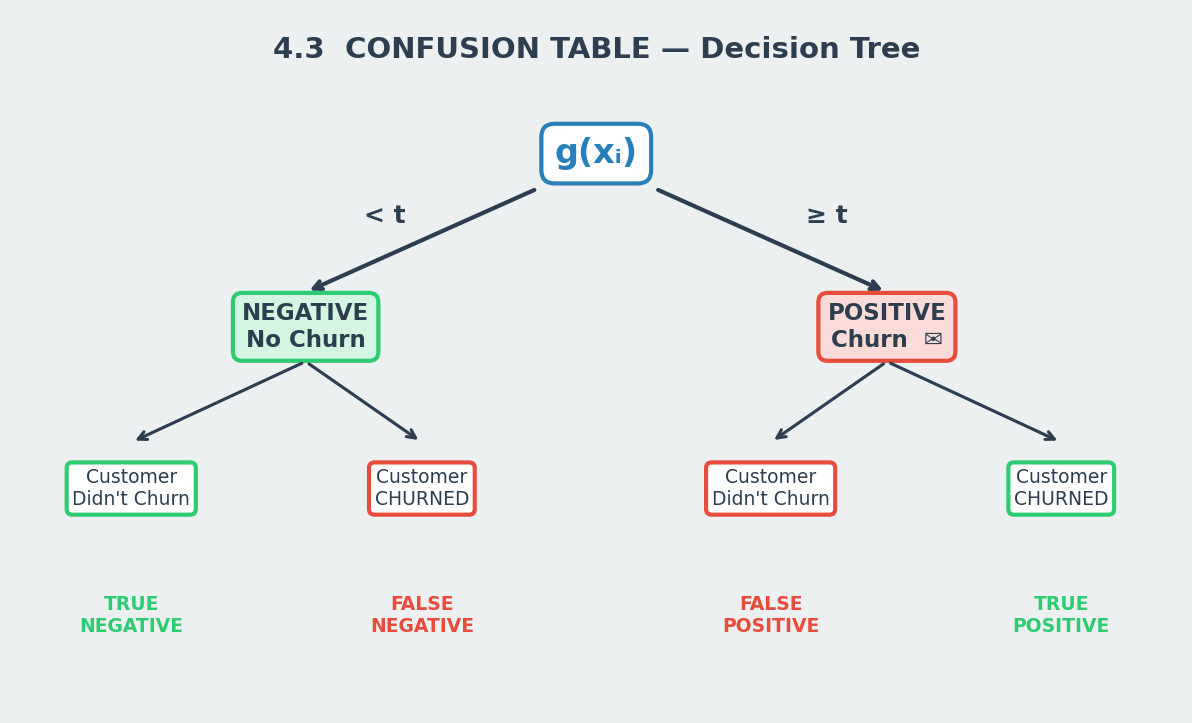
*Fig 1 — Decision tree: score vs threshold → TN / FN / FP / TP*

---

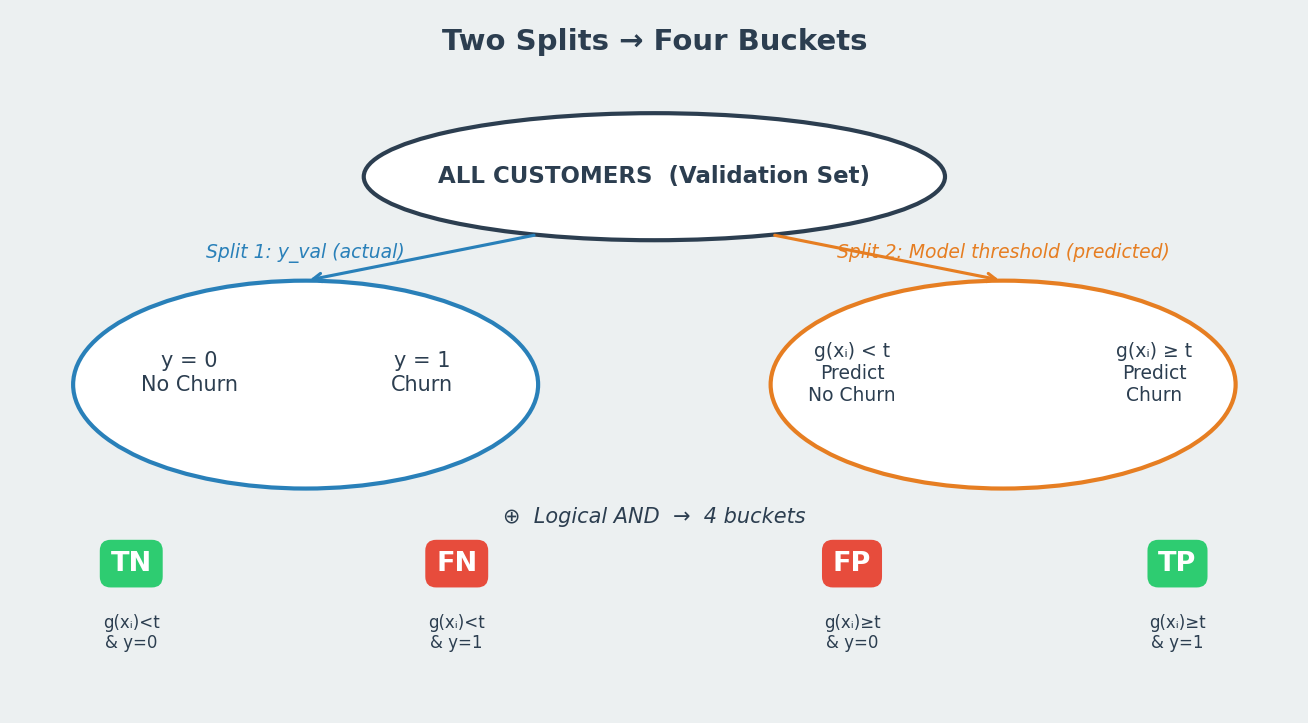
*Fig 2 — Two independent splits overlaid via logical AND → 4 outcome buckets*

---

## 🟩🟥 The Four Cells

| Cell | Condition | Plain English |
|---|---|---|
| **TN** | `g(xᵢ) < t` AND `y = 0` | Predicted no churn. Actually didn't churn. ✅ |
| **TP** | `g(xᵢ) ≥ t` AND `y = 1` | Predicted churn. Actually churned. ✅ |
| **FP** | `g(xᵢ) ≥ t` AND `y = 0` | Predicted churn. Actually didn't. ❌ |
| **FN** | `g(xᵢ) < t` AND `y = 1` | Predicted no churn. Actually churned. ❌ |

---

## 📊 The Confusion Matrix — Raw Counts

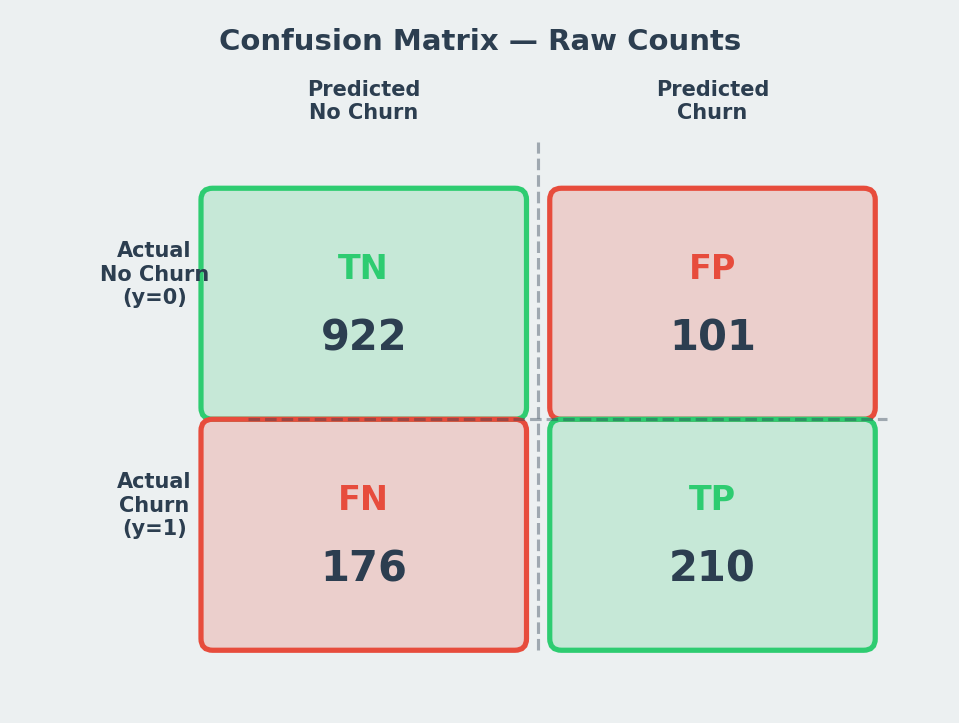
*Fig 3 — Confusion matrix: rows = actual, columns = predicted*

---

## 📐 Normalised View + Accuracy Breakdown

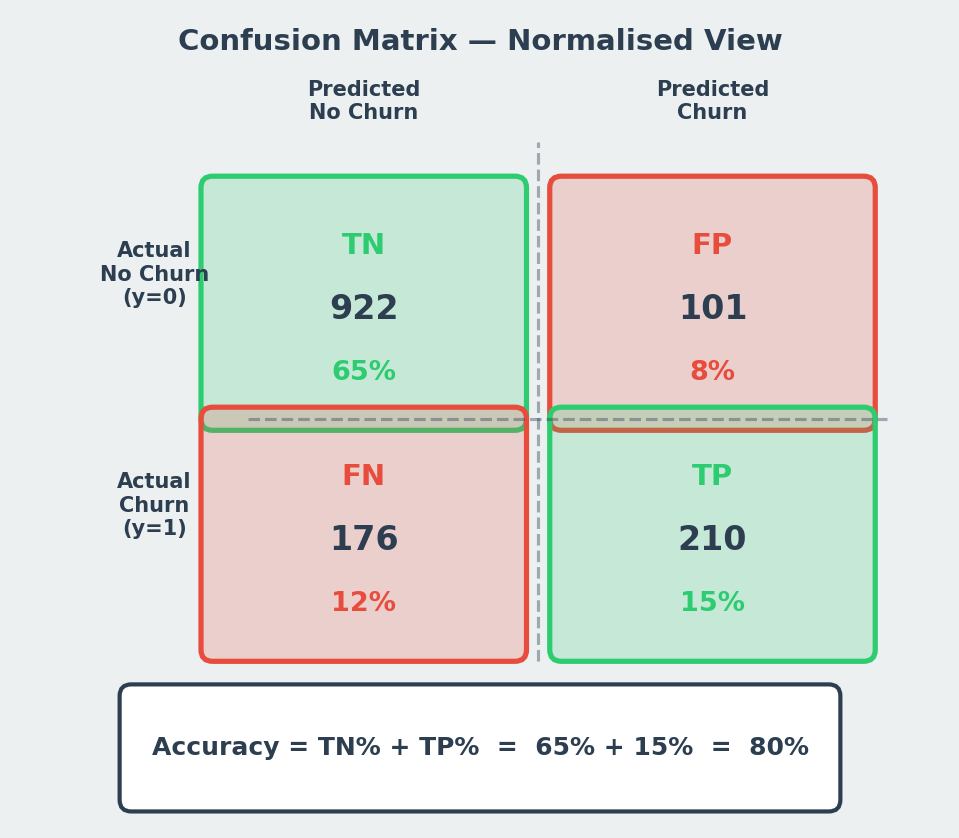
*Fig 4 — Normalised matrix: TN=65%, FP=8%, FN=12%, TP=15%. Accuracy = TN% + TP% = 80%*

---

## 💰 Business Cost Interpretation

| Cell | Count | % | Business Consequence |
|---|---|---|---|
| **TN** | 922 | 65% | Correct. No action. Zero cost. |
| **TP** | 210 | 15% | Correct. Sent discount. Customer retained. |
| **FP** | 101 | 8% | Sent discount to non-churner. Wasted ~£10/customer. |
| **FN** | 176 | 12% | Sent nothing. Customer churned. Revenue lost permanently. |

> **Critical asymmetry:** FN is the most expensive error — a customer who leaves stops paying forever. FP wastes a small discount. Accuracy treats TN and TP as equally valuable — but they are not.

---

## ✅ Concepts Locked This Session

| Concept | Status | Evidence |
|---|---|---|
| Confusion matrix built by logical AND of two arrays | ✅ Locked | Explained in own words |
| Accuracy = TN% + TP% — and why this misleads | ✅ Locked | Dummy model exploitation explained |
| Accuracy fails to expose FP/FN business impact | ✅ Locked | Stated correctly, unprompted |
| TN and TP are not equally valuable | ✅ Locked | Business consequence articulated |

---

## 🔨 Code Skeleton (In Progress)

```python
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC__Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X, y = df[features], df['Churn']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

# Step 5: Predict  ← FILL IN
y_pred = _______________

# Step 6: Build confusion matrix  ← FILL IN
cm = confusion_matrix(_______________, _______________)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Churn Confusion Matrix")
plt.show()
```

**Blanks:**
1. `y_pred = ___` — what sklearn method gives predicted class labels (0 or 1)?
2. `confusion_matrix(___, ___)` — actual or predicted first? Why does order matter?

---

## ⬜ What's Next

- Complete the code skeleton
- Add normalised view (`normalize='all'`)
- Add business cost annotation per cell
- **Session 2:** Precision, Recall, F1

---

*Source: MLOps Zoomcamp — Session 4, Lesson 3 (Confusion Table)*